# Grain boundary operations: MCGS2D

This notebook introduces grain boundary operations in a MCGS2D.We will focus on boundary extraction, segmentation, and junction point characterization and visualiztion.

### Objectives
The primary objectives of this notebook are to:
- Generate MCGS2D and use a temporal slice as the grain strucrue of anlaysis.
- Compute grain morphology metadata required for boundary-level analysis.
- Detect GB and construct segmented grain boundary representations.
- Identify and classify GB junction points by topological order.
- Visualize global and feature-level grain-boundary segment networks.

### Important variables
The notebook operates on previously computed in-memory variables, including:
- `gstslice` (the grain-structure slice selected for GB operartions),
- `lfi_padded` (padded label field, padded with unit pixel in all directions, to ensure closed boundary grains),
- `gbMask` (grain boundary mask),
- `segments`, `nsegments` (boundary segment topology related data),
- `gbsegs` (individual gb segments),
- `junctions` and `jps_by_order` (junction-point sets and grouping by JP orderi.e. JPO).

### Expected data/outputs
By the end of this workflow, the notebook provides:
- validated grain-boundary segmentation maps,
- per-feature segment visualization utilities,
- junction-point classification summaries (e.g., order-3 and order-4 points),
- visualizations supporting qualitative inspection of boundary topology.

## 1. Environment setup

In [1]:
from upxo.ggrowth.mcgs import mcgs
import numpy as np
import matplotlib.pyplot as plt

In [2]:
input_dashboard = 'C:\\Development\\UPXO\\upxo_library\\src\\upxo\\demos\\gschar\\gschar2.xls'

## 2. GS generation and characterisaion

The simulation is executed, grains are detected, and the final temporal slice is selected.
Neighbor relationships are then computed and cleaned to remove self-references before boundary operations.

In [3]:
pxt = mcgs(input_dashboard=input_dashboard)
pxt.simulate()
pxt.detect_grains(library='cc3d', process_individual_states=True)
gstslice = pxt.gs[pxt.m[-1]]
gstslice.char_morph_2d(npixels=True)
gstslice.find_neigh(include_central_grain=False, print_msg=True, use_numba=True,
                     user_defined_bbox_ex_bounds=False, bbox_ex_bounds=None,
                     update_grain_object=True)
# Due to an existing bvug, we will manually remove the central gid from neighs as below.
for gid in gstslice.neigh_gid.keys():
    if gid in gstslice.neigh_gid[gid]:
        gstslice.neigh_gid[gid].remove(gid)
#gstslice.neigh_gid

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\demos\gschar\gschar2.xls
Algo_hops details
(('200.0', 100),)
[False]

 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 50.0, 1.0
     ymin, ymax, yinc: 0.0, 50.0, 1.0
     zmin, zmax, zinc: 0.0, 25.0, 1.0
     No. of states: 8
     Dimensionality: 2
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
GS temporal slice 7 stored
GS temporal slice 8 stored
GS temporal slice 9 stored
GS temporal slice 10 stored
GS temporal slice 11 stored
GS temporal slice 12 stored
GS temporal slice 13 stored
GS temporal slice 14 stored
GS temporal slice 15 stored
GS temporal slice 16 stored
GS temporal slice 17 stored
GS tem

## 3. Grain boundary identificartion
The lfi represernation is padded, GB pixels are identified. _NOTE: The reason for padding has bneen provided at the beginning, please refer back if in doubt._

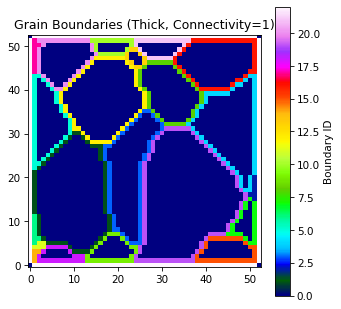

In [4]:
lfi_padded = gstslice.pad_lfi()
gbMask = gstslice.find_gb(lfi_padded, plot_gb=True, figsize=(5, 5), dpi=75, cmap='gist_ncar')

## 4. Grain boundary segment identification
`lfi` and `gbMask` is used to extract the GB segments (i.e. `gbsegs`).

In [5]:
segments, nsegments = gstslice.segment_gb(lfi_padded, gbMask, gstslice.neigh_gid, connectivity=8)

Now that we ghave extracted the asegment coordinates, we will translate these into a sepertate image data structure using the below `make_gbsegImage` function. We will later visualize these.

In [6]:
gbsegs = gstslice.make_gbsegImage(gbMask, segments, nsegments, gstslice.neigh_gid)
np.unique(gbsegs)

array([ 0.    ,  1.    ,  1.1429,  1.2857,  1.4286,  1.5714,  1.7143,
        1.8571,  2.    ,  2.3333,  2.6667,  3.    ,  3.2   ,  3.4   ,
        3.6   ,  3.8   ,  4.    ,  4.25  ,  4.5   ,  4.75  ,  5.    ,
        5.25  ,  5.75  ,  6.    ,  6.5   ,  7.    ,  7.3333,  7.6667,
        8.    ,  8.1429,  8.2857,  8.4286,  8.5714,  8.7143,  8.8571,
        9.    ,  9.25  ,  9.5   ,  9.75  , 10.    , 10.25  , 10.5   ,
       10.75  , 11.25  , 11.5   , 11.75  , 12.    , 12.1429, 12.2857,
       12.4286, 12.5714, 12.7143, 12.8571, 13.5   , 13.75  , 14.5   ,
       15.    , 15.5   , 16.    , 16.3333, 16.6667, 17.5   , 18.    ,
       18.25  , 18.5   , 18.75  , 19.    , 19.1429, 19.2857, 19.4286,
       19.5714, 19.7143, 19.8571, 20.    , 20.25  , 20.5   , 20.75  ,
       21.    , 21.25  , 21.5   , 21.75  , 22.    ], dtype=float32)

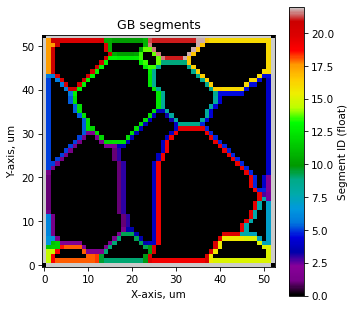

In [7]:
gstslice.see_all_gbsegs(gbsegs)

Lets visualize the segments of a certain grain,. In this case, we will choose the largest grain.

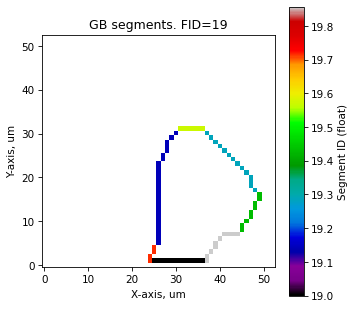

In [8]:
gstslice.see_gbsegs_fid(gbsegs, np.argmax(gstslice.prop.npixels.to_numpy())+1)

## 5. Extract junction points and group JPs by their order.

JPO is Junction point order, which tells how many grains a given JP gets shared with at the boundary. They are extracted from `gbsegs` and grouped by `JPO` to support further topological interpretation (`this further topological interpretation is under development for future releases of UPXO`).

In [9]:
junctions = gstslice.findJP(segments)

In [10]:
jps_by_order = gstslice.separate_junctions_by_order(junctions)

In [11]:
jps_by_order

{3: {1: array([[ 3, 12],
         [ 3, 13],
         [ 5,  4],
         [ 6,  3],
         [ 8, 18],
         [27, 16],
         [30, 10]]),
  2: array([[16, 51]]),
  3: array([[ 5, 24],
         [ 5, 25],
         [ 8, 19],
         [27, 17],
         [31, 30],
         [32, 30],
         [35, 26],
         [35, 27]]),
  4: array([[17, 49],
         [17, 50],
         [32, 36],
         [39, 40]]),
  5: array([[30,  9],
         [31,  9],
         [39,  6],
         [43,  1],
         [43,  2]]),
  6: array([[6, 1],
         [6, 2]]),
  7: array([[ 7, 45],
         [ 7, 46],
         [15, 50]]),
  8: array([[32, 31],
         [32, 35],
         [36, 27],
         [39, 39],
         [44, 25],
         [46, 27],
         [46, 32]]),
  9: array([[ 2, 13],
         [ 4, 24],
         [ 7, 18],
         [ 7, 19]]),
  10: array([[48, 16],
         [48, 21],
         [50, 23]]),
  11: array([[4, 1],
         [5, 2]]),
  12: array([[28, 16],
         [28, 17],
         [31, 10],
         [36,

## 6. Visualize gbsegs and jps

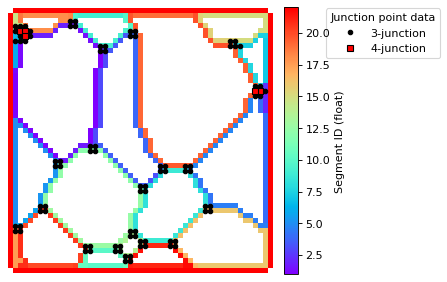

In [12]:
gstslice.see_gbsegs_jp_by_jpo(gbsegs, jps_by_order, style_by_order=None, default_style=None,
            figsize=(8, 8), dpi=80, legend_anchor=(1.2, 1.0), ms2=4,
            ms3=4, ms4=5, ms5=6, legend_loc='upper left', legend_title='Junction point data',
            legend_frameon=True, hide_axis=True, cmap='rainbow')

In [13]:
# import upxo.gsdataops.grid_ops as gridOps

In [14]:
# from skimage.segmentation import find_boundaries